<a href="https://colab.research.google.com/github/naitik-singh24/SCT_DS_2/blob/main/Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Titanic Dataset - Data cleaning & EDA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
from google.colab import files

# Upload 'train.csv'
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving train.csv to train.csv
User uploaded file "train.csv" with length 61194 bytes


In [5]:
pd.set_option('display.max_columns', None)

# Load Dataset

df = pd.read_csv('train.csv')

print("Dataset Shape: ", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape:  (891, 12)

First 5 Rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0      

In [6]:
# BASIC INFORMATION

print("\nDataset Information: ")
print(df.info())

print("\nMissing Values: ")
print(df.isnull().sum())

print("\nSummary Statistics: ")
print(df.describe())


Dataset Information: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Missing Values: 
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin   

In [7]:
# DATA CLEANING

df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


# Create Cabin Availability Feature & Drop Cabin column
df['Cabin_Available'] = df['Cabin'].notnull().astype(int)
df.drop('Cabin', axis=1, inplace=True)

print("\nMissing Values After Cleaning: ")
print(df.isnull().sum())






Missing Values After Cleaning: 
PassengerId        0
Survived           0
Pclass             0
Name               0
Sex                0
Age                0
SibSp              0
Parch              0
Ticket             0
Fare               0
Embarked           0
Cabin_Available    0
dtype: int64


/tmp/ipykernel_2030/3151441540.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_2030/3151441540.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [8]:
# EXPLORATORY DATA ANALYSIS

sns.set_style("whitegrid")
# sns.set_context("poster")

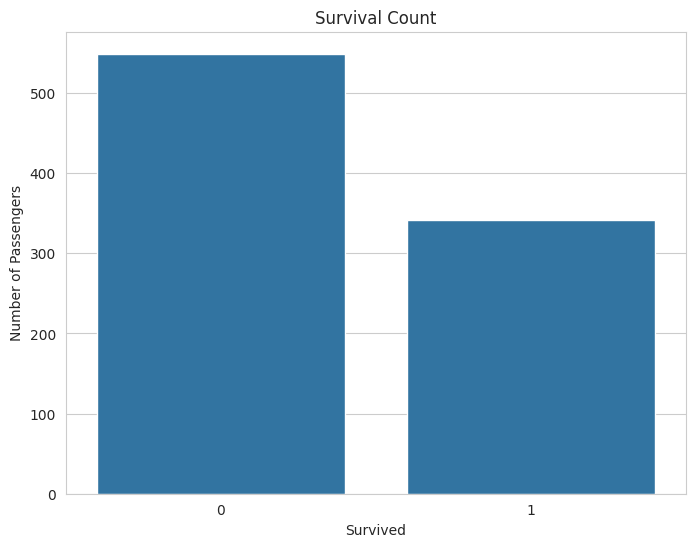

In [9]:
# SURVIVAL COUNT PLOT

plt.figure(figsize=(8,6))
sns.countplot(x='Survived', data=df)
plt.title('Survival Count')
plt.xlabel('Survived')
plt.ylabel('Number of Passengers')
plt.show()

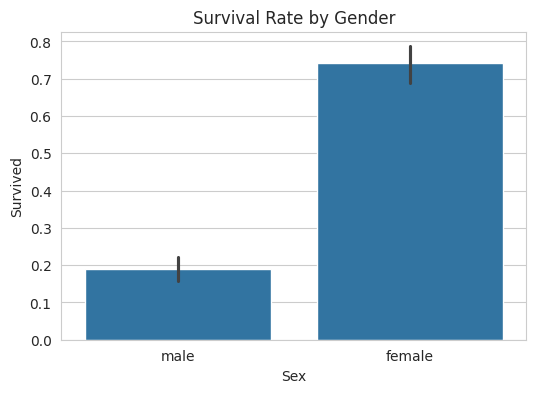

In [10]:
# SURVIVAL RATE BY GENDER

plt.figure(figsize=(6,4))
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate by Gender')
plt.show()

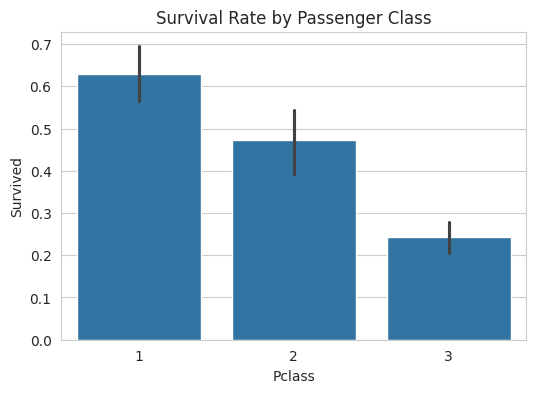

In [11]:
# SURVIVAL RATE BY PASSENGER CLASS

plt.figure(figsize=(6,4))
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Passenger Class')
plt.show()


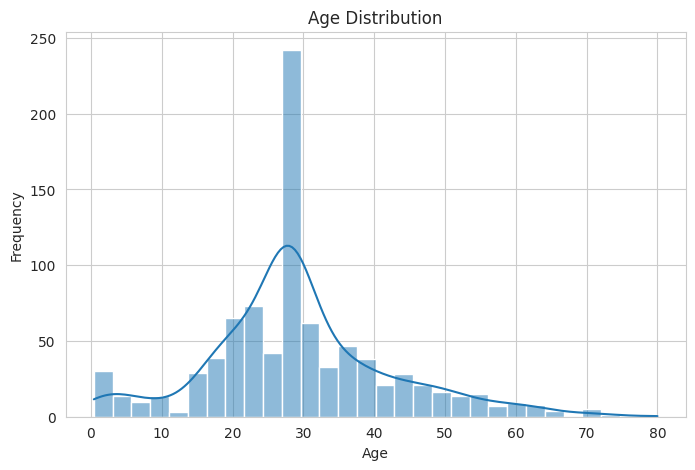

In [12]:
# AGE DISTRIBUTION

plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()
#


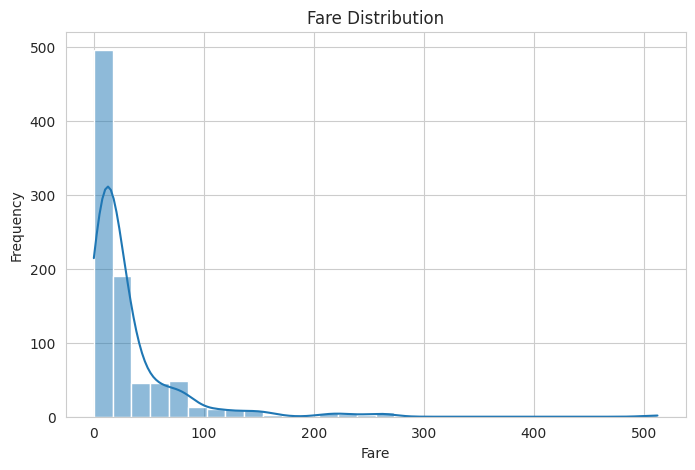

In [13]:
# FARE DISTRIBUTION

plt.figure(figsize=(8,5))
sns.histplot(df['Fare'], bins=30, kde=True)
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()
#

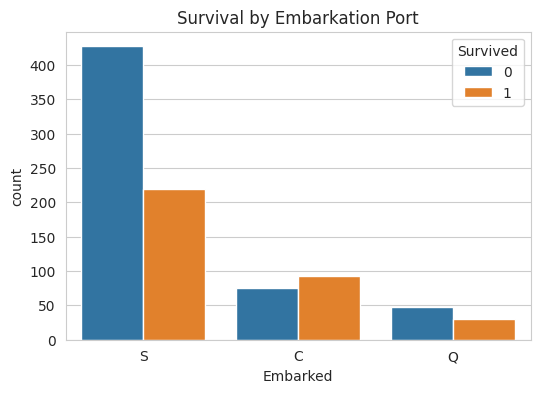

In [14]:
# SURVIVAL BY EMBARKATION PORT

plt.figure(figsize=(6,4))
sns.countplot(x='Embarked', hue='Survived', data=df)
plt.title('Survival by Embarkation Port')
plt.show()

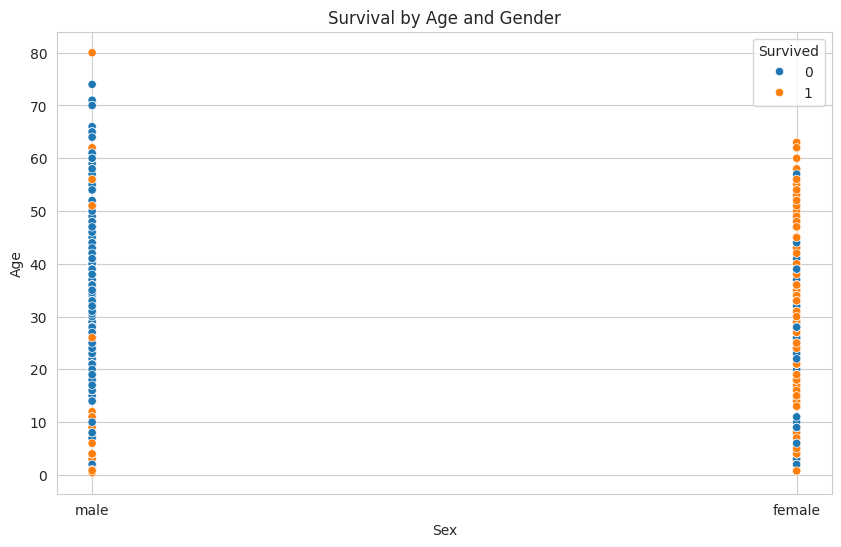

In [15]:
# SURVIVAL BY AGE AND GENDER

plt.figure(figsize=(10,6))
sns.scatterplot(x='Sex', y='Age', hue='Survived', data=df)
plt.title('Survival by Age and Gender')
plt.show()


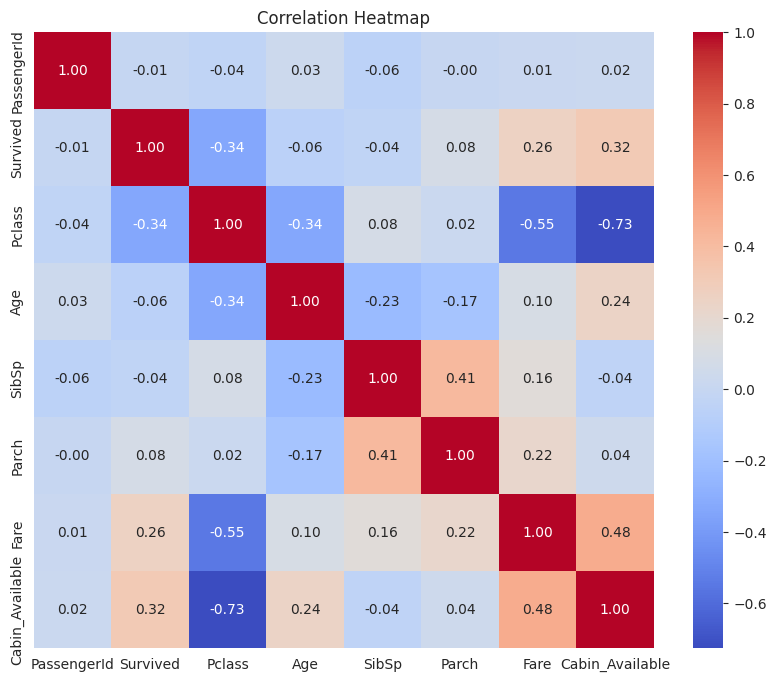

In [16]:
# CORRELATION HEATMAP

numereic_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))
sns.heatmap(numereic_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [17]:
# SURVIVAL PERCENTAGE

survival_percentage = df['Survived'].mean() * 100
print("\nOverall Survival Rate : {:.2f}%".format(survival_percentage))
print(f"Survival Percentage: {survival_percentage:.2f}%")


Overall Survival Rate : 38.38%
Survival Percentage: 38.38%


In [18]:
# GENDER-WISE SURVIVAL

gender_survival = df.groupby('Sex')['Survived'].mean() * 100
print("\nGender-wise Survival Rate:")
print(gender_survival)


Gender-wise Survival Rate:
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


In [19]:
# CLASS-WISE SURVIVAL

class_survival = df.groupby('Pclass')['Survived'].mean() * 100
print("\nClass-wise Survival Rate:")
print(class_survival)
#


Class-wise Survival Rate:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


In [20]:
# EMBARKED-WISE SURVIVAL

embark = df.groupby('Embarked')['Survived'].mean() * 100
print("\nEmbarked-wise Survival Rate:")
print(embark)

print("\nEDA Completed Successfully.......")


Embarked-wise Survival Rate:
Embarked
C    55.357143
Q    38.961039
S    33.900929
Name: Survived, dtype: float64

EDA Completed Successfully.......
